# Student Depression Prediction

Description:

- Analyzing Mental Health Trends and Predictors Among Students
- Target variable is **depression**: A binary indicator (0/1) that denotes whether a student is experiencing depression

Note: Data was undersampled to obtain a 70-30 imbalance to avoid bias when feeding data into the model.

Key Objectives:
1. Analyze mental health trends among students using EDA and statistical analyses.
2. Identify strongest risk factors that predict student depression using machine learning models.
3. Recommend high-level interventions/strategies in educational environments.

## 1. Loading/Observing the Data

In [94]:
# Import packages

# general libraries
import re
import time
import json
import pickle
import warnings
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
from collections import Counter
warnings.filterwarnings("ignore")

# visualizations
import seaborn as sns
from termcolor import colored
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# modelling
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (train_test_split, GridSearchCV, RandomizedSearchCV,
                                     StratifiedKFold)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier,
                              GradientBoostingClassifier)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, roc_auc_score)

# imbalanced techniques
from imblearn.pipeline import Pipeline, make_pipeline
from imblearn.over_sampling import (SMOTE, ADASYN, BorderlineSMOTE, SVMSMOTE)
from imblearn.under_sampling import (TomekLinks, NearMiss, AllKNN,
                                     EditedNearestNeighbours,
                                     RepeatedEditedNearestNeighbours)
from imblearn.combine import SMOTETomek, SMOTEENN

# interpretability
import shap

# model deployment
from flask import Flask
import streamlit as st

In [2]:
# Load the data
depression_resampled = pd.read_csv('student_depression_resampled.csv', index_col=0)
depression_resampled

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,131388,Female,33.0,Vasai-Virar,Student,5.0,0.0,5.64,3.0,0.0,'More than 8 hours',Healthy,B.Com,No,0.0,3.0,No,0
1,126172,Male,22.0,Kolkata,Student,1.0,0.0,7.09,3.0,0.0,'Less than 5 hours',Healthy,B.Arch,No,1.0,1.0,No,0
2,16241,Male,21.0,Kalyan,Student,1.0,0.0,7.53,1.0,0.0,'5-6 hours',Healthy,MA,No,11.0,3.0,No,0
3,9430,Male,30.0,Pune,Student,3.0,0.0,5.57,4.0,0.0,'Less than 5 hours',Unhealthy,M.Tech,Yes,1.0,3.0,Yes,0
4,1856,Male,26.0,Agra,Student,1.0,0.0,9.50,4.0,0.0,'More than 8 hours',Healthy,MBBS,Yes,7.0,4.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16516,77032,Male,24.0,Ahmedabad,Student,4.0,0.0,8.73,4.0,0.0,'More than 8 hours',Unhealthy,B.Arch,No,8.0,3.0,Yes,0
16517,85651,Male,20.0,Thane,Student,3.0,0.0,8.23,4.0,0.0,'Less than 5 hours',Moderate,'Class 12',No,0.0,4.0,Yes,0
16518,5462,Female,22.0,Nagpur,Student,3.0,0.0,8.07,1.0,0.0,'Less than 5 hours',Unhealthy,MSc,Yes,10.0,2.0,No,0
16519,81007,Male,25.0,Kanpur,Student,5.0,0.0,8.59,1.0,0.0,'Less than 5 hours',Moderate,B.Ed,Yes,3.0,5.0,Yes,1


In [3]:
#Display shape
depression_resampled.shape

(16521, 18)

In [4]:
#Check type of data of columns in dataframe
depression_resampled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16521 entries, 0 to 16520
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     16521 non-null  int64  
 1   Gender                                 16521 non-null  object 
 2   Age                                    16521 non-null  float64
 3   City                                   16521 non-null  object 
 4   Profession                             16521 non-null  object 
 5   Academic Pressure                      16521 non-null  float64
 6   Work Pressure                          16521 non-null  float64
 7   CGPA                                   16521 non-null  float64
 8   Study Satisfaction                     16521 non-null  float64
 9   Job Satisfaction                       16521 non-null  float64
 10  Sleep Duration                         16521 non-null  object 
 11  Dietary

In [5]:
#Check number of respondents for a certain feature/column
depression_resampled['Financial Stress'].value_counts()

Financial Stress
1.0    3992
2.0    3580
3.0    3062
4.0    3006
5.0    2879
?         2
Name: count, dtype: int64

In [6]:
#Check % of target variable (depression)
depression_resampled['Depression'].value_counts(normalize = True) * 100

Depression
0    70.001816
1    29.998184
Name: proportion, dtype: float64

In [7]:
#Check for duplicate data in id (a unique identifier)
depression_resampled.duplicated(subset = 'id', keep = False).sum().item()

0

In [8]:
#Check for missing/null data
depression_resampled.isna().sum()

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64

## 2. Data Preprocessing

In [9]:
#Drop unnecessary columns/variables
drop = ['City']
depression_resampled_dropped = depression_resampled.drop(drop, axis=1)
depression_resampled_dropped

,id,Gender,Age,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,131388,Female,33.0,Student,5.0,0.0,5.64,3.0,0.0,'More than 8 hours',Healthy,B.Com,No,0.0,3.0,No,0
1,126172,Male,22.0,Student,1.0,0.0,7.09,3.0,0.0,'Less than 5 hours',Healthy,B.Arch,No,1.0,1.0,No,0
2,16241,Male,21.0,Student,1.0,0.0,7.53,1.0,0.0,'5-6 hours',Healthy,MA,No,11.0,3.0,No,0
3,9430,Male,30.0,Student,3.0,0.0,5.57,4.0,0.0,'Less than 5 hours',Unhealthy,M.Tech,Yes,1.0,3.0,Yes,0
4,1856,Male,26.0,Student,1.0,0.0,9.50,4.0,0.0,'More than 8 hours',Healthy,MBBS,Yes,7.0,4.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16516,77032,Male,24.0,Student,4.0,0.0,8.73,4.0,0.0,'More than 8 hours',Unhealthy,B.Arch,No,8.0,3.0,Yes,0
16517,85651,Male,20.0,Student,3.0,0.0,8.23,4.0,0.0,'Less than 5 hours',Moderate,'Class 12',No,0.0,4.0,Yes,0
16518,5462,Female,22.0,Student,3.0,0.0,8.07,1.0,0.0,'Less than 5 hours',Unhealthy,MSc,Yes,10.0,2.0,No,0
16519,81007,Male,25.0,Student,5.0,0.0,8.59,1.0,0.0,'Less than 5 hours',Moderate,B.Ed,Yes,3.0,5.0,Yes,1


In [10]:
#Perform data masking for Student ID as it is considered sensitive data
import hashlib
import pandas as pd

data_masked = depression_resampled_dropped.copy()
data_masked.columns = data_masked.columns.str.strip().str.lower()

if 'id' in data_masked.columns:
    def hash_id(x):
        if pd.isna(x):
            return None
        return hashlib.sha256(str(x).encode()).hexdigest()

    data_masked['id_masked'] = data_masked['id'].apply(hash_id)
    data_masked=data_masked.drop(columns=['id'])
else:
    print("Column 'id' not found. Available columns:", data_clean.columns.tolist())

data_masked  #can try to replace with asterisk for last 4 digits

,gender,age,profession,academic pressure,work pressure,cgpa,study satisfaction,job satisfaction,sleep duration,dietary habits,degree,have you ever had suicidal thoughts ?,work/study hours,financial stress,family history of mental illness,depression,id_masked
0,Female,33.0,Student,5.0,0.0,5.64,3.0,0.0,'More than 8 hours',Healthy,B.Com,No,0.0,3.0,No,0,cbc493e26ff1e184fff1ca5dd6fad46a2dd250d2b94de0...
1,Male,22.0,Student,1.0,0.0,7.09,3.0,0.0,'Less than 5 hours',Healthy,B.Arch,No,1.0,1.0,No,0,d8e4de65ca237f546ff2213f8f59b4b3a6c19612f5d879...
2,Male,21.0,Student,1.0,0.0,7.53,1.0,0.0,'5-6 hours',Healthy,MA,No,11.0,3.0,No,0,4b0e6319833596d58072abae8af94102ae54198c138514...
3,Male,30.0,Student,3.0,0.0,5.57,4.0,0.0,'Less than 5 hours',Unhealthy,M.Tech,Yes,1.0,3.0,Yes,0,4c61a70becbc2a160646dc8928b718d02ecf2b980e505c...
4,Male,26.0,Student,1.0,0.0,9.50,4.0,0.0,'More than 8 hours',Healthy,MBBS,Yes,7.0,4.0,No,0,c17ec73c802422d05391fbab496c2c62d81885e435bb31...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16516,Male,24.0,Student,4.0,0.0,8.73,4.0,0.0,'More than 8 hours',Unhealthy,B.Arch,No,8.0,3.0,Yes,0,54df2bc339c71f6b19eabdbe37d3e7d50b13405fd8364c...
16517,Male,20.0,Student,3.0,0.0,8.23,4.0,0.0,'Less than 5 hours',Moderate,'Class 12',No,0.0,4.0,Yes,0,10d36d5bf352377f81eeafe10f8fc3bf87b054c78580c7...
16518,Female,22.0,Student,3.0,0.0,8.07,1.0,0.0,'Less than 5 hours',Unhealthy,MSc,Yes,10.0,2.0,No,0,971787b181dd876b7154510d935cf06620bdb2584ac0c3...
16519,Male,25.0,Student,5.0,0.0,8.59,1.0,0.0,'Less than 5 hours',Moderate,B.Ed,Yes,3.0,5.0,Yes,1,c2f14195fb73fd43bb38072af7429707ca0c97ab8abc30...


## 3. Data Preprocessing (Feature Engineering)

**Gender, Suicidal Thoughts, Family History:** Binary Encoding

In [11]:
mapping_binary = {
    'Yes': 1,
    'No': 0,
    'Male': 0,
    'Female': 1
}
data_cleaned = data_masked.copy()
data_cleaned['gender'] = data_cleaned['gender'].map(mapping_binary)
data_cleaned['have you ever had suicidal thoughts ?'] = data_cleaned['have you ever had suicidal thoughts ?'].map(mapping_binary)
data_cleaned['family history of mental illness'] = data_cleaned['family history of mental illness'].map(mapping_binary)

**Age:** Type Casting → Binning → Ordinal Encoding

In [12]:
# Step 1: Convert float to int
data_cleaned['age'] = data_cleaned['age'].astype(int)

# Step 2: Bin into decade groups
bins   = [17, 19, 29, 39, 49, 59]
labels = ['Teens', '20s', '30s', '40s', '50s']

data_cleaned['age group'] = pd.cut(data_cleaned['age'], bins=bins, labels=labels)

# Step 3: Ordinal encode
age_order = {
    'Teens': 1,
    '20s'  : 2,
    '30s'  : 3,
    '40s'  : 4,
    '50s'  : 5
}
data_cleaned['age group'] = data_cleaned['age group'].map(age_order)
data_cleaned.drop(columns=['age'], inplace=True)

**Profession:** Quote Stripping → Binary Encoding

In [13]:
# Collapse into binary — Student vs Non-Student
data_cleaned['profession'] = data_cleaned['profession'].str.strip("'")  # fix 'Digital Marketer'
data_cleaned['profession'] = data_cleaned['profession'].map(
    lambda x: 1 if x == 'Student' else 0
)

**CGPA**: Rounding off

In [14]:
# Step 1: Round off CGPA scores to the nearest whole number. Note that India's CGPA grading system follows a 10-point scale.
data_cleaned['cgpa'] = data_cleaned['cgpa'].round()
data_cleaned['cgpa'].value_counts()

cgpa
6.0     3659
9.0     3360
8.0     3260
7.0     2895
10.0    2258
5.0     1083
0.0        6
Name: count, dtype: int64

**Sleep Duration:** Quote Stripping → Handling 'Others' → Ordinal Encoding

In [15]:
# Step 1: Strip embedded single quotes
data_cleaned['sleep duration'] = data_cleaned['sleep duration'].str.strip("'")

# Step 2: Handle 'Others' — replace with NaN then fill with mode
data_cleaned['sleep duration'] = data_cleaned['sleep duration'].replace('Others', pd.NA)
data_cleaned['sleep duration'] = data_cleaned['sleep duration'].fillna(data_cleaned['sleep duration'].mode()[0])

# Step 3: Ordinal encoding (natural sleep order)
sleep_order = {
    'Less than 5 hours': 1,
    '5-6 hours'        : 2,
    '7-8 hours'        : 3,
    'More than 8 hours': 4
}
data_cleaned['sleep duration'] = data_cleaned['sleep duration'].map(sleep_order)

**Dietary Habits:** Handling 'Others' → Ordinal Encoding

In [16]:
# Step 1: Handle 'Others' — replace with mode
data_cleaned['dietary habits'] = data_cleaned['dietary habits'].replace('Others', pd.NA)
data_cleaned['dietary habits'] = data_cleaned['dietary habits'].fillna(data_cleaned['dietary habits'].mode()[0])

# Step 2: Ordinal encoding (unhealthy → healthy order)
diet_order = {
    'Unhealthy': 1,
    'Moderate' : 2,
    'Healthy'  : 3
}
data_cleaned['dietary habits'] = data_cleaned['dietary habits'].map(diet_order)

**Degree:** Quote Stripping → Grouping → Ordinal Encoding

In [17]:
# Step 1: Strip embedded single quotes
data_cleaned['degree'] = data_cleaned['degree'].str.strip("'")

# Step 2: Group into education levels
def group_degree(deg):
    postgrad  = ['MSc','M.Tech','MCA','M.Ed','M.Com','MBA','MA','M.Pharm',
                 'MD','MHM','ME','LLM','PhD']
    undergrad = ['B.Ed','B.Com','B.Arch','BCA','B.Tech','BHM','B.Pharm',
                 'BSc','BBA','LLB','BE','BA','MBBS','BEd']
    secondary = ['Class 12']
    if deg in postgrad:    return 'Postgraduate'
    elif deg in undergrad: return 'Undergraduate'
    elif deg in secondary: return 'Secondary'
    else:                  return 'Other'

data_cleaned['degree level'] = data_cleaned['degree'].apply(group_degree)
data_cleaned.drop(columns=['degree'], inplace=True)  # drop original

# Step 3: Ordinal encoding (education progression)
degree_order = {
    'Secondary'    : 1,
    'Undergraduate': 2,
    'Postgraduate' : 3,
    'Other'        : 0
}
data_cleaned['degree level'] = data_cleaned['degree level'].map(degree_order)

**Financial Stress:** Handling '?'

In [18]:
# Step 1: Handle '?' — replace with NaN then fill with mode
data_cleaned['financial stress'] = data_cleaned['financial stress'].replace('?', pd.NA)
data_cleaned['financial stress'] = data_cleaned['financial stress'].fillna(data_cleaned['financial stress'].mode()[0])

In [19]:
data_cleaned

,gender,profession,academic pressure,work pressure,cgpa,study satisfaction,job satisfaction,sleep duration,dietary habits,have you ever had suicidal thoughts ?,work/study hours,financial stress,family history of mental illness,depression,id_masked,age group,degree level
0,1,1,5.0,0.0,6.0,3.0,0.0,4,3,0,0.0,3.0,0,0,cbc493e26ff1e184fff1ca5dd6fad46a2dd250d2b94de0...,3,2
1,0,1,1.0,0.0,7.0,3.0,0.0,1,3,0,1.0,1.0,0,0,d8e4de65ca237f546ff2213f8f59b4b3a6c19612f5d879...,2,2
2,0,1,1.0,0.0,8.0,1.0,0.0,2,3,0,11.0,3.0,0,0,4b0e6319833596d58072abae8af94102ae54198c138514...,2,3
3,0,1,3.0,0.0,6.0,4.0,0.0,1,1,1,1.0,3.0,1,0,4c61a70becbc2a160646dc8928b718d02ecf2b980e505c...,3,3
4,0,1,1.0,0.0,10.0,4.0,0.0,4,3,1,7.0,4.0,0,0,c17ec73c802422d05391fbab496c2c62d81885e435bb31...,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16516,0,1,4.0,0.0,9.0,4.0,0.0,4,1,0,8.0,3.0,1,0,54df2bc339c71f6b19eabdbe37d3e7d50b13405fd8364c...,2,2
16517,0,1,3.0,0.0,8.0,4.0,0.0,1,2,0,0.0,4.0,1,0,10d36d5bf352377f81eeafe10f8fc3bf87b054c78580c7...,2,1
16518,1,1,3.0,0.0,8.0,1.0,0.0,1,1,1,10.0,2.0,0,0,971787b181dd876b7154510d935cf06620bdb2584ac0c3...,2,3
16519,0,1,5.0,0.0,9.0,1.0,0.0,1,2,1,3.0,5.0,1,1,c2f14195fb73fd43bb38072af7429707ca0c97ab8abc30...,2,2


In [20]:
#Rename existing columns to make them more readable
data_cleaned = data_cleaned.rename(
    columns = {
        'have you ever had suicidal thoughts ?': 'suicidal thoughts'
        }
)
data_cleaned

,gender,profession,academic pressure,work pressure,cgpa,study satisfaction,job satisfaction,sleep duration,dietary habits,suicidal thoughts,work/study hours,financial stress,family history of mental illness,depression,id_masked,age group,degree level
0,1,1,5.0,0.0,6.0,3.0,0.0,4,3,0,0.0,3.0,0,0,cbc493e26ff1e184fff1ca5dd6fad46a2dd250d2b94de0...,3,2
1,0,1,1.0,0.0,7.0,3.0,0.0,1,3,0,1.0,1.0,0,0,d8e4de65ca237f546ff2213f8f59b4b3a6c19612f5d879...,2,2
2,0,1,1.0,0.0,8.0,1.0,0.0,2,3,0,11.0,3.0,0,0,4b0e6319833596d58072abae8af94102ae54198c138514...,2,3
3,0,1,3.0,0.0,6.0,4.0,0.0,1,1,1,1.0,3.0,1,0,4c61a70becbc2a160646dc8928b718d02ecf2b980e505c...,3,3
4,0,1,1.0,0.0,10.0,4.0,0.0,4,3,1,7.0,4.0,0,0,c17ec73c802422d05391fbab496c2c62d81885e435bb31...,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16516,0,1,4.0,0.0,9.0,4.0,0.0,4,1,0,8.0,3.0,1,0,54df2bc339c71f6b19eabdbe37d3e7d50b13405fd8364c...,2,2
16517,0,1,3.0,0.0,8.0,4.0,0.0,1,2,0,0.0,4.0,1,0,10d36d5bf352377f81eeafe10f8fc3bf87b054c78580c7...,2,1
16518,1,1,3.0,0.0,8.0,1.0,0.0,1,1,1,10.0,2.0,0,0,971787b181dd876b7154510d935cf06620bdb2584ac0c3...,2,3
16519,0,1,5.0,0.0,9.0,1.0,0.0,1,2,1,3.0,5.0,1,1,c2f14195fb73fd43bb38072af7429707ca0c97ab8abc30...,2,2


In [21]:
#Save cleaned data set as new data frame
data_cleaned.to_csv(
    'depression_data_cleaned.csv',
    index=False
    )

In [22]:
data_cleaned = pd.read_csv('depression_data_cleaned.csv')
data_cleaned

,gender,profession,academic pressure,work pressure,cgpa,study satisfaction,job satisfaction,sleep duration,dietary habits,suicidal thoughts,work/study hours,financial stress,family history of mental illness,depression,id_masked,age group,degree level
0,1,1,5.0,0.0,6.0,3.0,0.0,4,3,0,0.0,3.0,0,0,cbc493e26ff1e184fff1ca5dd6fad46a2dd250d2b94de0...,3,2
1,0,1,1.0,0.0,7.0,3.0,0.0,1,3,0,1.0,1.0,0,0,d8e4de65ca237f546ff2213f8f59b4b3a6c19612f5d879...,2,2
2,0,1,1.0,0.0,8.0,1.0,0.0,2,3,0,11.0,3.0,0,0,4b0e6319833596d58072abae8af94102ae54198c138514...,2,3
3,0,1,3.0,0.0,6.0,4.0,0.0,1,1,1,1.0,3.0,1,0,4c61a70becbc2a160646dc8928b718d02ecf2b980e505c...,3,3
4,0,1,1.0,0.0,10.0,4.0,0.0,4,3,1,7.0,4.0,0,0,c17ec73c802422d05391fbab496c2c62d81885e435bb31...,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16516,0,1,4.0,0.0,9.0,4.0,0.0,4,1,0,8.0,3.0,1,0,54df2bc339c71f6b19eabdbe37d3e7d50b13405fd8364c...,2,2
16517,0,1,3.0,0.0,8.0,4.0,0.0,1,2,0,0.0,4.0,1,0,10d36d5bf352377f81eeafe10f8fc3bf87b054c78580c7...,2,1
16518,1,1,3.0,0.0,8.0,1.0,0.0,1,1,1,10.0,2.0,0,0,971787b181dd876b7154510d935cf06620bdb2584ac0c3...,2,3
16519,0,1,5.0,0.0,9.0,1.0,0.0,1,2,1,3.0,5.0,1,1,c2f14195fb73fd43bb38072af7429707ca0c97ab8abc30...,2,2


## 4. Performing Outlier Detection

Perform outlier detection using z-score for data_masked. Note this was the dataset before feature engineering was applied.

In [23]:
import pandas as pd
import numpy as np
from scipy.stats import zscore

# Select only numeric columns (exclude target if needed)
num_cols = data_masked.select_dtypes(include=['int64', 'float64']).columns
num_cols = num_cols.drop(['depression'])  # exclude target

# Compute Z-scores
z_scores = np.abs(zscore(data_masked[num_cols]))

# Set threshold
threshold = 3

# Identify outliers (True = outlier)
outliers = (z_scores > threshold)

# Count outliers per column
outlier_counts = outliers.sum(axis=0)

print("Outliers per column:\n", outlier_counts)

Outliers per column:
 [14  0  2  6  0  5  0]


## 5. Data Preprocessing - Others

Check distributions of **numerical** features. Note this was the dataset **before** feature engineering was applied.

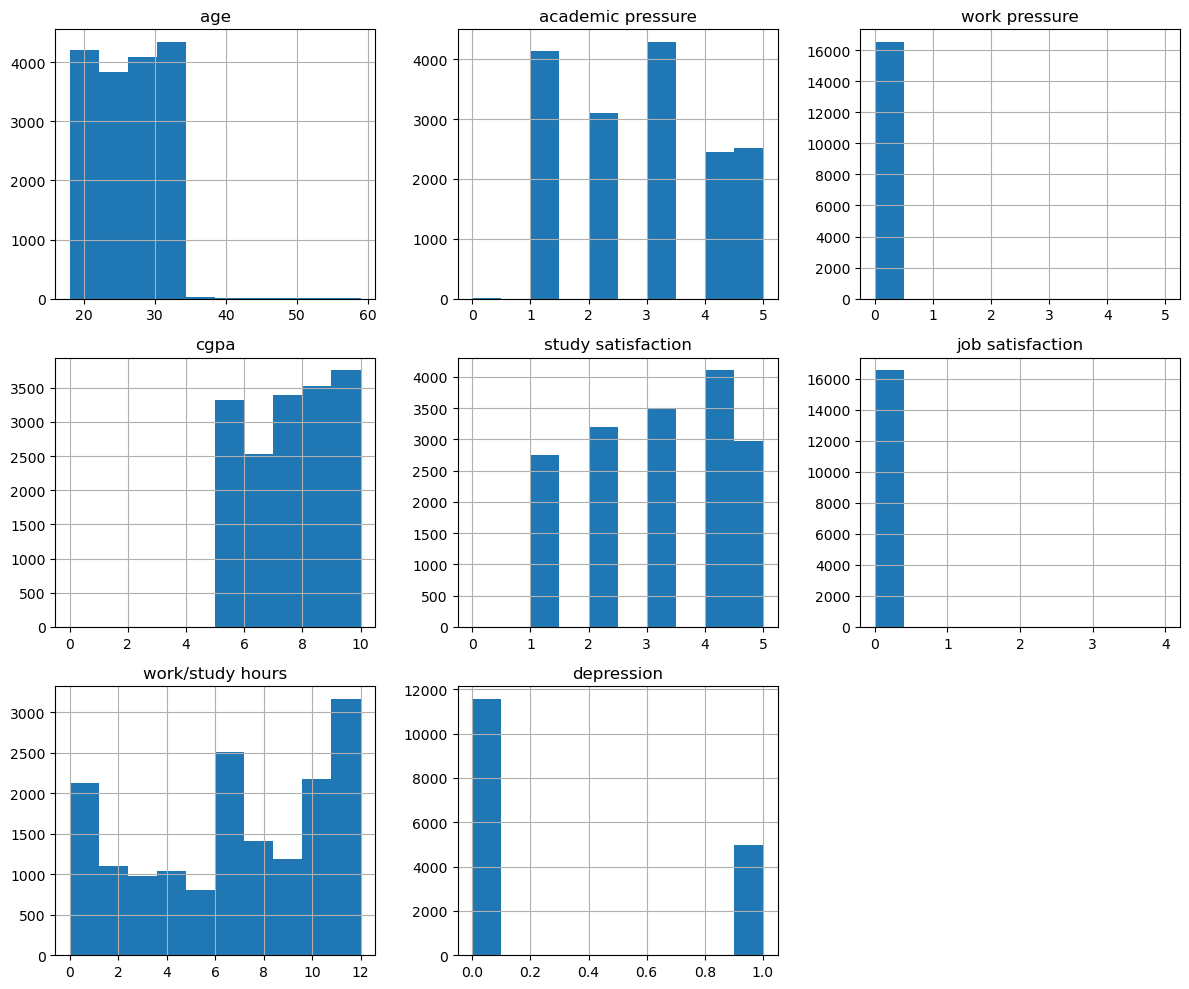

In [24]:
import matplotlib.pyplot as plt

numerical_cols = data_masked.select_dtypes(include=['float64', 'int64']).columns

data_masked[numerical_cols].hist(figsize=(12,10))
plt.tight_layout()
plt.show()

#Ask: Need to have columns above as standardized distributions? Can be part of feature selection

Check values of **categorical** features. Note this was the dataset **before** feature engineering was applied.

In [25]:
for col in data_masked.select_dtypes(include='object').columns:
    print(f"\n{col}")
    print(data_masked[col].value_counts())


gender
gender
Male      9205
Female    7316
Name: count, dtype: int64

profession
profession
Student               16514
Architect                 4
Teacher                   1
Chef                      1
'Digital Marketer'        1
Name: count, dtype: int64

sleep duration
sleep duration
'Less than 5 hours'    4582
'7-8 hours'            4289
'More than 8 hours'    3868
'5-6 hours'            3767
Others                   15
Name: count, dtype: int64

dietary habits
dietary habits
Moderate     6066
Healthy      5231
Unhealthy    5214
Others         10
Name: count, dtype: int64

degree
degree
'Class 12'    3082
B.Ed          1165
B.Com          912
B.Arch         875
BCA            847
MSc            728
B.Tech         704
M.Tech         665
MCA            652
BHM            579
B.Pharm        525
BSc            521
M.Ed           519
M.Com          452
BBA            415
LLB            408
MBBS           405
BE             369
MD             367
M.Pharm        367
BA             363


In [26]:
data_cleaned.to_csv(r"data_cleaned.csv",index=False)

In [27]:
data_cleaned

,gender,profession,academic pressure,work pressure,cgpa,study satisfaction,job satisfaction,sleep duration,dietary habits,suicidal thoughts,work/study hours,financial stress,family history of mental illness,depression,id_masked,age group,degree level
0,1,1,5.0,0.0,6.0,3.0,0.0,4,3,0,0.0,3.0,0,0,cbc493e26ff1e184fff1ca5dd6fad46a2dd250d2b94de0...,3,2
1,0,1,1.0,0.0,7.0,3.0,0.0,1,3,0,1.0,1.0,0,0,d8e4de65ca237f546ff2213f8f59b4b3a6c19612f5d879...,2,2
2,0,1,1.0,0.0,8.0,1.0,0.0,2,3,0,11.0,3.0,0,0,4b0e6319833596d58072abae8af94102ae54198c138514...,2,3
3,0,1,3.0,0.0,6.0,4.0,0.0,1,1,1,1.0,3.0,1,0,4c61a70becbc2a160646dc8928b718d02ecf2b980e505c...,3,3
4,0,1,1.0,0.0,10.0,4.0,0.0,4,3,1,7.0,4.0,0,0,c17ec73c802422d05391fbab496c2c62d81885e435bb31...,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16516,0,1,4.0,0.0,9.0,4.0,0.0,4,1,0,8.0,3.0,1,0,54df2bc339c71f6b19eabdbe37d3e7d50b13405fd8364c...,2,2
16517,0,1,3.0,0.0,8.0,4.0,0.0,1,2,0,0.0,4.0,1,0,10d36d5bf352377f81eeafe10f8fc3bf87b054c78580c7...,2,1
16518,1,1,3.0,0.0,8.0,1.0,0.0,1,1,1,10.0,2.0,0,0,971787b181dd876b7154510d935cf06620bdb2584ac0c3...,2,3
16519,0,1,5.0,0.0,9.0,1.0,0.0,1,2,1,3.0,5.0,1,1,c2f14195fb73fd43bb38072af7429707ca0c97ab8abc30...,2,2


## 6. Exploratory Data Analysis (EDA)

### Prepare data_masked dataset for EDA

In [28]:
# Clean needed columns directly in data_masked
data_masked['age'] = data_masked['age'].astype(int)
data_masked['gender'] = data_masked['gender'].astype(str).str.strip()
data_masked['profession'] = data_masked['profession'].astype(str).str.strip().str.strip("'")
data_masked['depression'] = pd.to_numeric(data_masked['depression'], errors='coerce')

# Reintroduce readable depression label
data_masked['depression_label'] = data_masked['depression'].map({
    0: 'Not Depressed',
    1: 'Depressed'
})

# Binary profession version for simpler EDA
data_masked['profession_binary'] = np.where(
    data_masked['profession'] == 'Student',
    'Student',
    'Non-Student'
)

# Add age bins directly into data_masked
bins   = [17, 19, 29, 39, 49, 59]
labels = ['Teens', '20s', '30s', '40s', '50s']

data_masked['age_group'] = pd.cut(data_masked['age'], bins=bins, labels=labels)

# Quick check
display(data_masked[['age', 'age_group', 'gender', 'profession', 'profession_binary', 'depression']].head(20))

,age,age_group,gender,profession,profession_binary,depression
0,33,30s,Female,Student,Student,0
1,22,20s,Male,Student,Student,0
2,21,20s,Male,Student,Student,0
3,30,30s,Male,Student,Student,0
4,26,20s,Male,Student,Student,0
5,18,Teens,Male,Student,Student,0
6,25,20s,Male,Student,Student,0
7,20,20s,Male,Student,Student,1
8,24,20s,Male,Student,Student,0
9,25,20s,Female,Student,Student,0


### Respondent Profile Overview (Age, Gender, Profession)

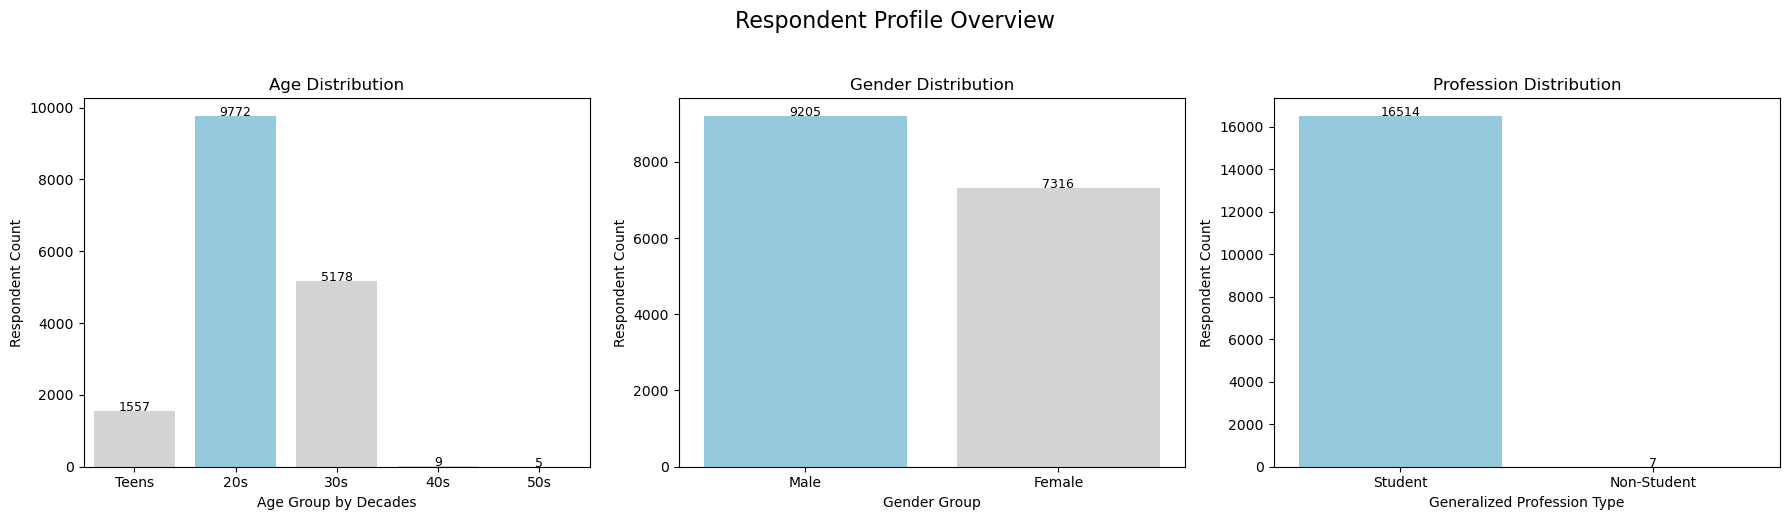

In [29]:
age_counts = data_masked['age_group'].value_counts().reindex(labels)
gender_counts = data_masked['gender'].value_counts()
prof_counts = data_masked['profession_binary'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Age ---
age_max = age_counts.idxmax()
age_colors = ['skyblue' if g == age_max else 'lightgray' for g in age_counts.index]

sns.barplot(x=age_counts.index, y=age_counts.values, palette=age_colors, ax=axes[0])
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age Group by Decades')
axes[0].set_ylabel('Respondent Count')
for i, v in enumerate(age_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontsize=9)

# --- Gender ---
gender_max = gender_counts.idxmax()
gender_colors = ['skyblue' if g == gender_max else 'lightgray' for g in gender_counts.index]

sns.barplot(x=gender_counts.index, y=gender_counts.values, palette=gender_colors, ax=axes[1])
axes[1].set_title('Gender Distribution')
axes[1].set_xlabel('Gender Group')
axes[1].set_ylabel('Respondent Count')
for i, v in enumerate(gender_counts.values):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontsize=9)

# --- Profession ---
prof_max = prof_counts.idxmax()
prof_colors = ['skyblue' if g == prof_max else 'lightgray' for g in prof_counts.index]

sns.barplot(x=prof_counts.index, y=prof_counts.values, palette=prof_colors, ax=axes[2])
axes[2].set_title('Profession Distribution')
axes[2].set_xlabel('Generalized Profession Type')
axes[2].set_ylabel('Respondent Count')
for i, v in enumerate(prof_counts.values):
    axes[2].text(i, v + 0.5, str(v), ha='center', fontsize=9)

plt.suptitle('Respondent Profile Overview', fontsize=16, y=1.03)
plt.tight_layout()
plt.show()

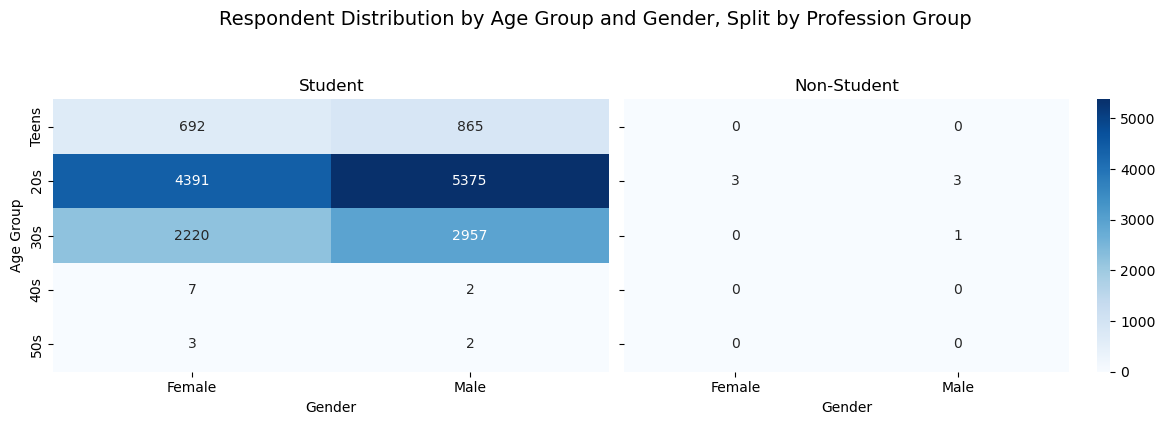

In [30]:
prof_groups = ['Student', 'Non-Student']

all_counts = []
for prof in prof_groups:
    temp = data_masked[data_masked['profession_binary'] == prof]

    count_table = pd.pivot_table(
        temp,
        index='age_group',
        columns='gender',
        values='profession_binary',
        aggfunc='count'
    )
    
    all_counts.append(count_table)

# Use same color scale for fair comparison
global_min = min(t.min().min() for t in all_counts)
global_max = max(t.max().max() for t in all_counts)

fig, axes = plt.subplots(1, len(prof_groups), figsize=(12, 4), sharey=True)

if len(prof_groups) == 1:
    axes = [axes]

for i, prof in enumerate(prof_groups):
    count_table = all_counts[i].fillna(0)
    
    sns.heatmap(
        count_table,
        annot=True,
        fmt='.0f',
        cmap='Blues',
        vmin=global_min,
        vmax=global_max,
        cbar=(i == len(prof_groups) - 1),
        ax=axes[i]
    )

    axes[i].set_title(f'{prof}')
    axes[i].set_xlabel('Gender')
    axes[i].set_ylabel('Age Group' if i == 0 else '')

plt.suptitle('Respondent Distribution by Age Group and Gender, Split by Profession Group', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

### Depression Rate Across Key Demographic Groups

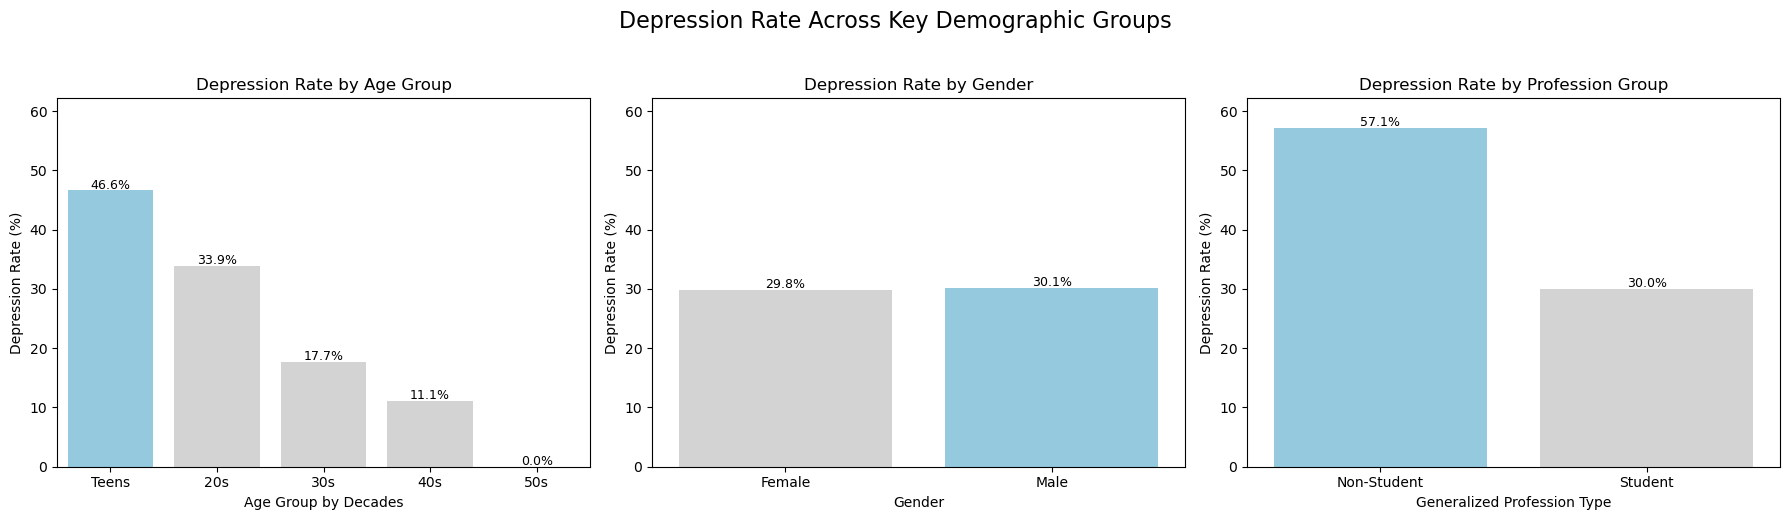

In [31]:
# Compute depression rates (%)
age_dep = (
    data_masked.groupby('age_group', observed=False)['depression']
    .mean()
    .reindex(labels) * 100
)

gender_dep = (
    data_masked.groupby('gender', observed=False)['depression']
    .mean() * 100
)

prof_bin_dep = (
    data_masked.groupby('profession_binary', observed=False)['depression']
    .mean() * 100
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Age Group ---
age_max = age_dep.idxmax()
age_colors = ['skyblue' if g == age_max else 'lightgray' for g in age_dep.index]

sns.barplot(
    x=age_dep.index,
    y=age_dep.values,
    palette=age_colors,
    ax=axes[0]
)
axes[0].set_title('Depression Rate by Age Group')
axes[0].set_xlabel('Age Group by Decades')
axes[0].set_ylabel('Depression Rate (%)')
axes[0].set_ylim(0, max(age_dep.max(), gender_dep.max(), prof_bin_dep.max()) + 5)

for i, v in enumerate(age_dep.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

# --- Gender ---
gender_max = gender_dep.idxmax()
gender_colors = ['skyblue' if g == gender_max else 'lightgray' for g in gender_dep.index]

sns.barplot(
    x=gender_dep.index,
    y=gender_dep.values,
    palette=gender_colors,
    ax=axes[1]
)
axes[1].set_title('Depression Rate by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Depression Rate (%)')
axes[1].set_ylim(0, max(age_dep.max(), gender_dep.max(), prof_bin_dep.max()) + 5)

for i, v in enumerate(gender_dep.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

# --- Profession Binary ---
prof_max = prof_bin_dep.idxmax()
prof_colors = ['skyblue' if g == prof_max else 'lightgray' for g in prof_bin_dep.index]

sns.barplot(
    x=prof_bin_dep.index,
    y=prof_bin_dep.values,
    palette=prof_colors,
    ax=axes[2]
)
axes[2].set_title('Depression Rate by Profession Group')
axes[2].set_xlabel('Generalized Profession Type')
axes[2].set_ylabel('Depression Rate (%)')
axes[2].set_ylim(0, max(age_dep.max(), gender_dep.max(), prof_bin_dep.max()) + 5)

for i, v in enumerate(prof_bin_dep.values):
    axes[2].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

plt.suptitle('Depression Rate Across Key Demographic Groups', fontsize=16, y=1.03)
plt.tight_layout()
plt.show()

### Distribution of Academic Pressure

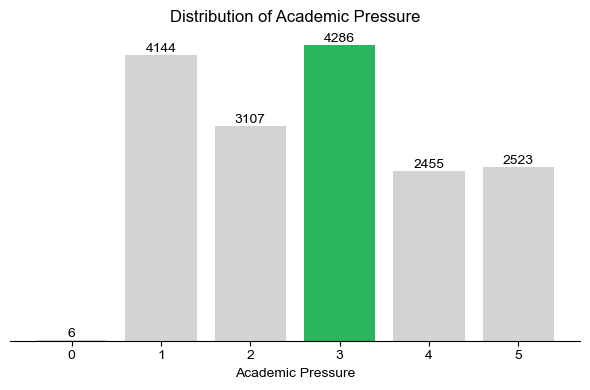

In [32]:
# Set font to Arial
plt.rcParams['font.family'] = 'Arial'

# Count the number of records per Academic Pressure value
acad_pressure_count = data_masked['academic pressure'].value_counts().sort_index()

# Identify the maximum count
max_value = acad_pressure_count.max()

# Assign colors: green for max, gray for others
colors = [
    '#2BB65E' if value == max_value else '#D3D3D3'
    for value in acad_pressure_count.values
]

# Create figure
plt.figure(figsize=(6,4), dpi=100)

# Plot bar chart
bars = plt.bar(
    acad_pressure_count.index,
    acad_pressure_count.values,
    color=colors
)

# Labels and title
plt.xlabel("Academic Pressure")
plt.title("Distribution of Academic Pressure")

# Ensure x-axis shows only actual values
plt.xticks(acad_pressure_count.index)

# Remove y-axis
plt.gca().yaxis.set_visible(False)

# Remove unnecessary borders
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)

# Add value labels above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=10
    )

# Adjust layout
plt.tight_layout()

# Show chart
plt.show()

### Academic Pressure vs. Depression

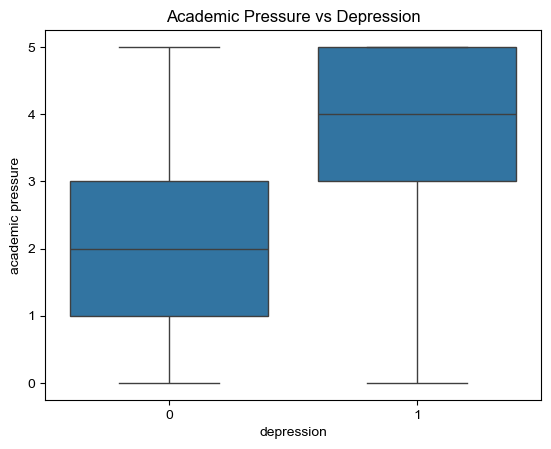

In [33]:
sns.boxplot(x='depression', y='academic pressure', data=data_masked)
plt.title("Academic Pressure vs Depression")
plt.show()

### Correlation Analysis

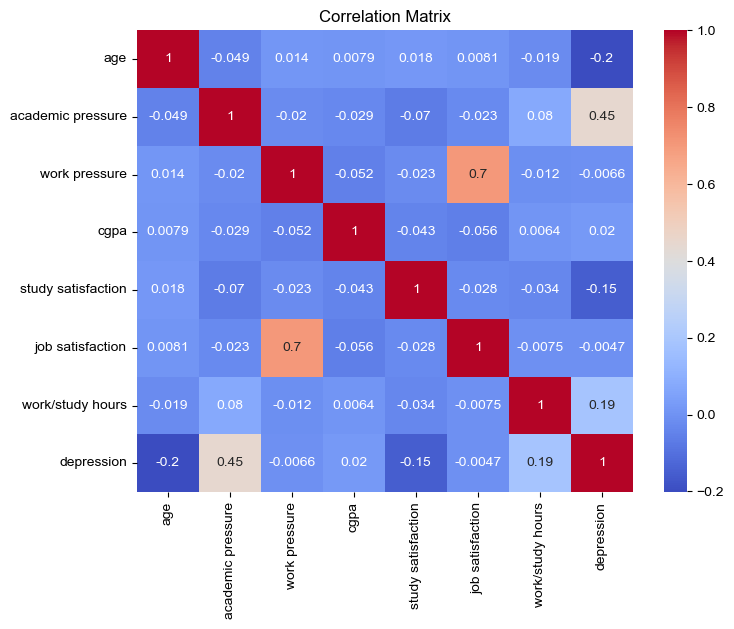

In [34]:
corr = data_masked.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### Distribution for Depressed vs Not Depressed

Class
not depressed    11565
depressed         4956
Name: count, dtype: int64

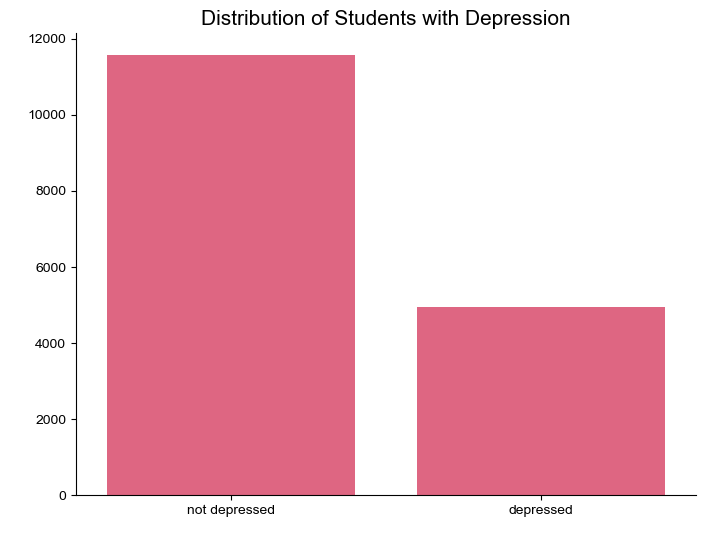

In [35]:
depression_map = {0: 'not depressed', 1: 'depressed'}
depression_eda = data_cleaned.copy()
depression_eda['Class'] = depression_eda['depression'].map(depression_map)

fig, ax = plt.subplots(figsize=(8, 6))
ax = sns.countplot(x=depression_eda['Class'],
              order=depression_eda['Class'].value_counts().index,
              color="#F25278")
ax.set_xlabel(' ')
ax.set_ylabel(' ')
for spine in ['right', 'top']:
    ax.spines[spine].set_visible(False)
ax.set_title(f'Distribution of Students with Depression', size=15, y=1)
display(depression_eda['Class'].value_counts())
plt.show()

### Distribution for Financial Stress

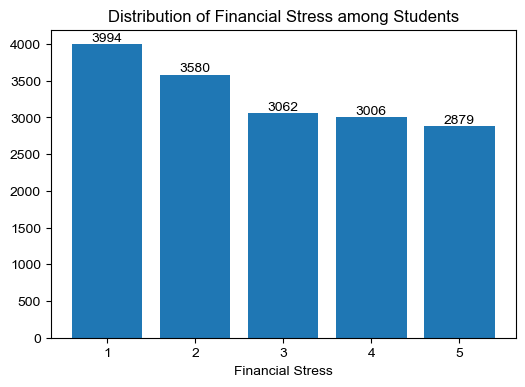

In [36]:
financial_stress_eda = data_cleaned['financial stress'].value_counts().sort_index()
max_value = financial_stress_eda.max()
plt.figure(figsize=(6,4), dpi=100)
bars = plt.bar(
    financial_stress_eda.index,
    financial_stress_eda.values
)
plt.xlabel("Financial Stress")
plt.title("Distribution of Financial Stress among Students")

#add value labels in each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=10
    )
plt.show()

## 7. Modeling

In [149]:
df = pd.read_csv("data_cleaned.csv")

In [150]:
df.head()

,gender,profession,academic pressure,work pressure,cgpa,study satisfaction,job satisfaction,sleep duration,dietary habits,suicidal thoughts,work/study hours,financial stress,family history of mental illness,depression,id_masked,age group,degree level
0,1,1,5.0,0.0,6.0,3.0,0.0,4,3,0,0.0,3.0,0,0,cbc493e26ff1e184fff1ca5dd6fad46a2dd250d2b94de0...,3,2
1,0,1,1.0,0.0,7.0,3.0,0.0,1,3,0,1.0,1.0,0,0,d8e4de65ca237f546ff2213f8f59b4b3a6c19612f5d879...,2,2
2,0,1,1.0,0.0,8.0,1.0,0.0,2,3,0,11.0,3.0,0,0,4b0e6319833596d58072abae8af94102ae54198c138514...,2,3
3,0,1,3.0,0.0,6.0,4.0,0.0,1,1,1,1.0,3.0,1,0,4c61a70becbc2a160646dc8928b718d02ecf2b980e505c...,3,3
4,0,1,1.0,0.0,10.0,4.0,0.0,4,3,1,7.0,4.0,0,0,c17ec73c802422d05391fbab496c2c62d81885e435bb31...,2,2


In [151]:
df.shape

(16521, 17)

In [152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16521 entries, 0 to 16520
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   gender                            16521 non-null  int64  
 1   profession                        16521 non-null  int64  
 2   academic pressure                 16521 non-null  float64
 3   work pressure                     16521 non-null  float64
 4   cgpa                              16521 non-null  float64
 5   study satisfaction                16521 non-null  float64
 6   job satisfaction                  16521 non-null  float64
 7   sleep duration                    16521 non-null  int64  
 8   dietary habits                    16521 non-null  int64  
 9   suicidal thoughts                 16521 non-null  int64  
 10  work/study hours                  16521 non-null  float64
 11  financial stress                  16521 non-null  float64
 12  fami

In [153]:
df = df.rename(columns = {
    "academic pressure" : "academic_pressure"
    ,"work pressure" : "work_pressure"
    ,"study satisfaction" : "study_satisfaction"
    ,"job satisfaction" : "job_satisfaction"
    ,"sleep duration" : "sleep_duration"
    ,"dietary habits" : "dietary_habits"
    ,"suicidal thoughts" : "suicidal_thoughts"
    ,"work/study hours" : "work_study_hours"
    ,"financial stress" : "financial_stress"
    ,"family history of mental illness" : "family_history_mental_illness"
    ,"age group" : "age_group"
    ,"degree level" : "degree_level"
})

### Train-Test Split

In [154]:
# These columns are removed because they have small significance for the prediction (based on feature importance result)
df = df.drop(columns = ['work_pressure', 'job_satisfaction', 'profession', 'cgpa', 'gender'])

In [155]:
df

,academic_pressure,study_satisfaction,sleep_duration,dietary_habits,suicidal_thoughts,work_study_hours,financial_stress,family_history_mental_illness,depression,id_masked,age_group,degree_level
0,5.0,3.0,4,3,0,0.0,3.0,0,0,cbc493e26ff1e184fff1ca5dd6fad46a2dd250d2b94de0...,3,2
1,1.0,3.0,1,3,0,1.0,1.0,0,0,d8e4de65ca237f546ff2213f8f59b4b3a6c19612f5d879...,2,2
2,1.0,1.0,2,3,0,11.0,3.0,0,0,4b0e6319833596d58072abae8af94102ae54198c138514...,2,3
3,3.0,4.0,1,1,1,1.0,3.0,1,0,4c61a70becbc2a160646dc8928b718d02ecf2b980e505c...,3,3
4,1.0,4.0,4,3,1,7.0,4.0,0,0,c17ec73c802422d05391fbab496c2c62d81885e435bb31...,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...
16516,4.0,4.0,4,1,0,8.0,3.0,1,0,54df2bc339c71f6b19eabdbe37d3e7d50b13405fd8364c...,2,2
16517,3.0,4.0,1,2,0,0.0,4.0,1,0,10d36d5bf352377f81eeafe10f8fc3bf87b054c78580c7...,2,1
16518,3.0,1.0,1,1,1,10.0,2.0,0,0,971787b181dd876b7154510d935cf06620bdb2584ac0c3...,2,3
16519,5.0,1.0,1,2,1,3.0,5.0,1,1,c2f14195fb73fd43bb38072af7429707ca0c97ab8abc30...,2,2


In [156]:
df_index = df.set_index('id_masked')
train, test = train_test_split(df_index, # input data
                               test_size=0.20, # target
                               random_state=42, # for reproducability
                               stratify=df['depression']) # to maintain the number of samples for each class
print(train.shape, test.shape)

(13216, 11) (3305, 11)


Would Recommend:       0
0  11565
1   4956
Proportion Chance Criterion: 58.00%
1.25 * Proportion Chance Criterion: 72.50%


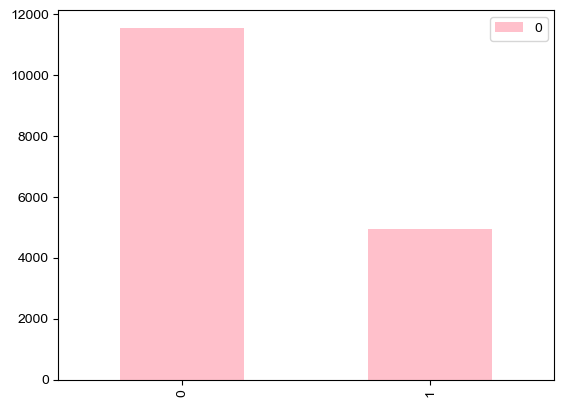

In [157]:
state_counts = Counter(df['depression'])
df_state = pd.DataFrame.from_dict(state_counts, orient='index')
df_state.plot(kind='bar', color='pink')

num=(df_state[0]/df_state[0].sum())**2

print("Would Recommend:{}".format(df_state))

print("Proportion Chance Criterion: {:0.2f}%".format(100*num.sum()))
print("1.25 * Proportion Chance Criterion: {:0.2f}%".format(1.25*100*num.sum()))

In [158]:
# Split train and test data into X (features) and y (target variable)
# All data
X = df.drop(['depression'], axis=1)
y = df['depression']

# Train
X_trainval = train.drop(['depression'], axis=1)
y_trainval = train['depression']

# Test
X_holdout = test.drop(['depression'], axis=1)
y_holdout = test['depression']

### Auto-ML

In [159]:
random_state = 42

In [160]:
def auto_ml(X, y, models_dict, scaler=None, cv=None, res_t=None):
    """Apply resampling for imbalanced data"""
    results = {}
    results2 = {}

    # log start time
    total_start = time.time()

    # get only num_col that exist in X (in case some were dropped)
    valid_num_cols = [col for col in num_col if col in X.columns]
    valid_cat_cols = [col for col in cat_col if col in X.columns]

    for model_name, model in tqdm(models_dict.items()):

        ################# this portion can be edited ###############
        train_scores = []
        val_scores = []
        train_recall = []
        val_recall = []
        train_auc = []
        val_auc = []
        ###########################################################

        # Define preprocessor once per model, not per fold
        if scaler is not None:
            preprocessor = ColumnTransformer(transformers=[
                ('scaler', scaler, valid_num_cols)
            ], remainder='passthrough')

        for train_index, val_index in tqdm(cv.split(X, y)):

            X_train, X_val = X.iloc[train_index], X.iloc[val_index]
            y_train, y_val = y.iloc[train_index], y.iloc[val_index]

            # Apply scaling on numeric columns only
            if scaler is not None:
                X_train = preprocessor.fit_transform(X_train)
                X_val = preprocessor.transform(X_val)
            else:
                pass

            # Apply resampling
            if res_t is not None:
                s = time.time()
                X_train, y_train = res_t.fit_resample(X_train, y_train)
                print(f'Resampling done in {time.time() - s}')
            else:
                pass

            start_time = time.time()

            # fit
            model.fit(X_train, y_train)

            # predict
            train_preds = model.predict(X_train)
            val_preds = model.predict(X_val)

            ################# this portion can be edited ###############

            # classification accuracy
            train_scores.append(model.score(X_train, y_train))
            val_scores.append(model.score(X_val, y_val))

            # recall
            train_recall.append(recall_score(y_train, train_preds))
            val_recall.append(recall_score(y_val, val_preds))

            # roc-auc (only for models that support predict_proba)
            try:
                train_auc.append(roc_auc_score(y_train, model.predict_proba(X_train)[:, 1]))
                val_auc.append(roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]))
            except AttributeError:
                train_auc.append(None)
                val_auc.append(None)

            end_time = time.time()

            results[model_name] = {
                'Train Accuracy': np.round(np.mean(train_scores) * 100, 2),
                'Val Accuracy': np.round(np.mean(val_scores) * 100, 2),
                'Train Recall': np.round(np.mean(train_recall) * 100, 2),
                'Val Recall': np.round(np.mean(val_recall) * 100, 2),
                'Train AUC': np.round(np.mean([a for a in train_auc if a is not None]) * 100, 2) if any(train_auc) else 'N/A',
                'Val AUC': np.round(np.mean([a for a in val_auc if a is not None]) * 100, 2) if any(val_auc) else 'N/A',
                'Run Time': end_time - start_time
            }

            results2[model_name] = {
                'Train Accuracy': '{:.2f}%'.format(np.round(np.mean(train_scores)*100, 2)),
                'Val Accuracy': '{:.2f}%'.format(np.round(np.mean(val_scores)*100, 2)),
                'Train Recall': '{:.2f}%'.format(np.round(np.mean(train_recall)*100, 2)),
                'Val Recall': '{:.2f}%'.format(np.round(np.mean(val_recall)*100, 2)),
                'Train AUC': '{:.2f}%'.format(np.round(np.mean([a for a in train_auc if a is not None]) * 100, 2)) if any(train_auc) else 'N/A',
                'Val AUC': '{:.2f}%'.format(np.round(np.mean([a for a in val_auc if a is not None]) * 100, 2)) if any(val_auc) else 'N/A',
                'Run Time': end_time - start_time
            }

            ###########################################################

    results = pd.DataFrame(results).T
    results2 = pd.DataFrame(results2).T
    return [results, results2]

In [161]:
num_col = [
    'work_study_hours',
]

cat_col = [
    'academic_pressure',
    'study_satisfaction',
    'sleep_duration',
    'dietary_habits',
    'suicidal_thoughts',
    'financial_stress',
    'family history of mental illness',
    'age_group',
    'family_history_mental_illness'
]

### Machine Learning

#### a. Baseline models

In [162]:
models_dict = {'LogisticRegressor': LogisticRegression(),
               'KNN Classifier': KNeighborsClassifier(),
               'RandomForestClassifier': RandomForestClassifier(random_state=random_state),
               'DecisionTreeClassifier': DecisionTreeClassifier(random_state=random_state),
               'GradientBoostingClassifier': GradientBoostingClassifier(random_state=random_state),
               'LightGBM': LGBMClassifier(random_state=random_state)}

In [163]:
auto_run = auto_ml(X_trainval, y_trainval, models_dict, scaler=RobustScaler(),
               cv=StratifiedKFold(n_splits=5))
auto = auto_run[0]
auto_run[1]

  0%|          | 0/6 [00:00<?, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

,Train Accuracy,Val Accuracy,Train Recall,Val Recall,Train AUC,Val AUC,Run Time
LogisticRegressor,86.13%,86.03%,73.46%,73.17%,92.10%,92.03%,0.022443
KNN Classifier,88.01%,83.29%,77.41%,69.48%,94.65%,86.95%,0.695762
RandomForestClassifier,99.66%,84.75%,99.29%,70.82%,100.00%,90.30%,0.761871
DecisionTreeClassifier,99.66%,78.86%,98.85%,66.10%,100.00%,75.37%,0.021612
GradientBoostingClassifier,86.71%,85.74%,74.09%,72.46%,92.78%,91.76%,0.502537
LightGBM,88.88%,85.52%,78.59%,73.24%,95.31%,91.32%,0.402723


#### b. Applying Resampling

##### i) Oversampling techniques

In [164]:
res_list = [('SMOTE', SMOTE()),
            ('ADASYN', ADASYN()),
            ('BorderlineSmote', BorderlineSMOTE())]

outputs = []
for title, res in res_list:
    print(colored(title, 'red', attrs=['bold']).center(120, "-"))
    var = auto_ml(X_trainval, y_trainval, models_dict, scaler=RobustScaler(),
                   cv=StratifiedKFold(n_splits=5), res_t=res)
    outputs.append(var[0])
    display(var[1])

---------------------------------------------------SMOTE---------------------------------------------------


  0%|          | 0/6 [00:00<?, ?it/s]

0it [00:00, ?it/s]

Resampling done in 0.03373289108276367
Resampling done in 0.04491019248962402
Resampling done in 0.05275321006774902
Resampling done in 0.07987403869628906
Resampling done in 0.09772014617919922


0it [00:00, ?it/s]

...

0it [00:00, ?it/s]

Resampling done in 0.08292913436889648
Resampling done in 0.08064579963684082
Resampling done in 0.08434009552001953
Resampling done in 0.08420181274414062
Resampling done in 0.08585715293884277


0it [00:00, ?it/s]

Resampling done in 0.10637021064758301
Resampling done in 0.08176898956298828
Resampling done in 0.08142709732055664
Resampling done in 0.08213305473327637
Resampling done in 0.0811002254486084


,Train Accuracy,Val Accuracy,Train Recall,Val Recall,Train AUC,Val AUC,Run Time
LogisticRegressor,82.17%,82.06%,84.86%,88.22%,89.24%,91.96%,0.033763
KNN Classifier,89.26%,76.53%,98.26%,82.72%,98.12%,84.08%,0.956648
RandomForestClassifier,99.75%,83.91%,99.74%,73.34%,100.00%,89.96%,1.192841
DecisionTreeClassifier,99.75%,78.31%,99.51%,66.58%,100.00%,75.07%,0.036839
GradientBoostingClassifier,88.99%,84.55%,91.37%,81.21%,95.83%,91.63%,0.909644
LightGBM,91.69%,85.00%,92.29%,76.24%,97.62%,91.36%,0.504944


In [165]:
ps_over = pd.DataFrame(index=models_dict.keys())
ps_over['NoResampling Val Recall'] = auto_run[0]['Val Recall']
ps_over['SMOTE Val Recall'] = outputs[0]['Val Recall']
ps_over['ADASYN Val Recall'] = outputs[1]['Val Recall']
ps_over['BorderlineSmote Val Recall'] = outputs[2]['Val Recall']
ps_over

,NoResampling Val Recall,SMOTE Val Recall,ADASYN Val Recall,BorderlineSmote Val Recall
LogisticRegressor,73.17,84.59,88.15,88.22
KNN Classifier,69.48,80.73,84.21,82.72
RandomForestClassifier,70.82,72.94,73.90,73.34
DecisionTreeClassifier,66.10,66.66,67.24,66.58
GradientBoostingClassifier,72.46,79.02,80.15,81.21
LightGBM,73.24,75.33,76.12,76.24


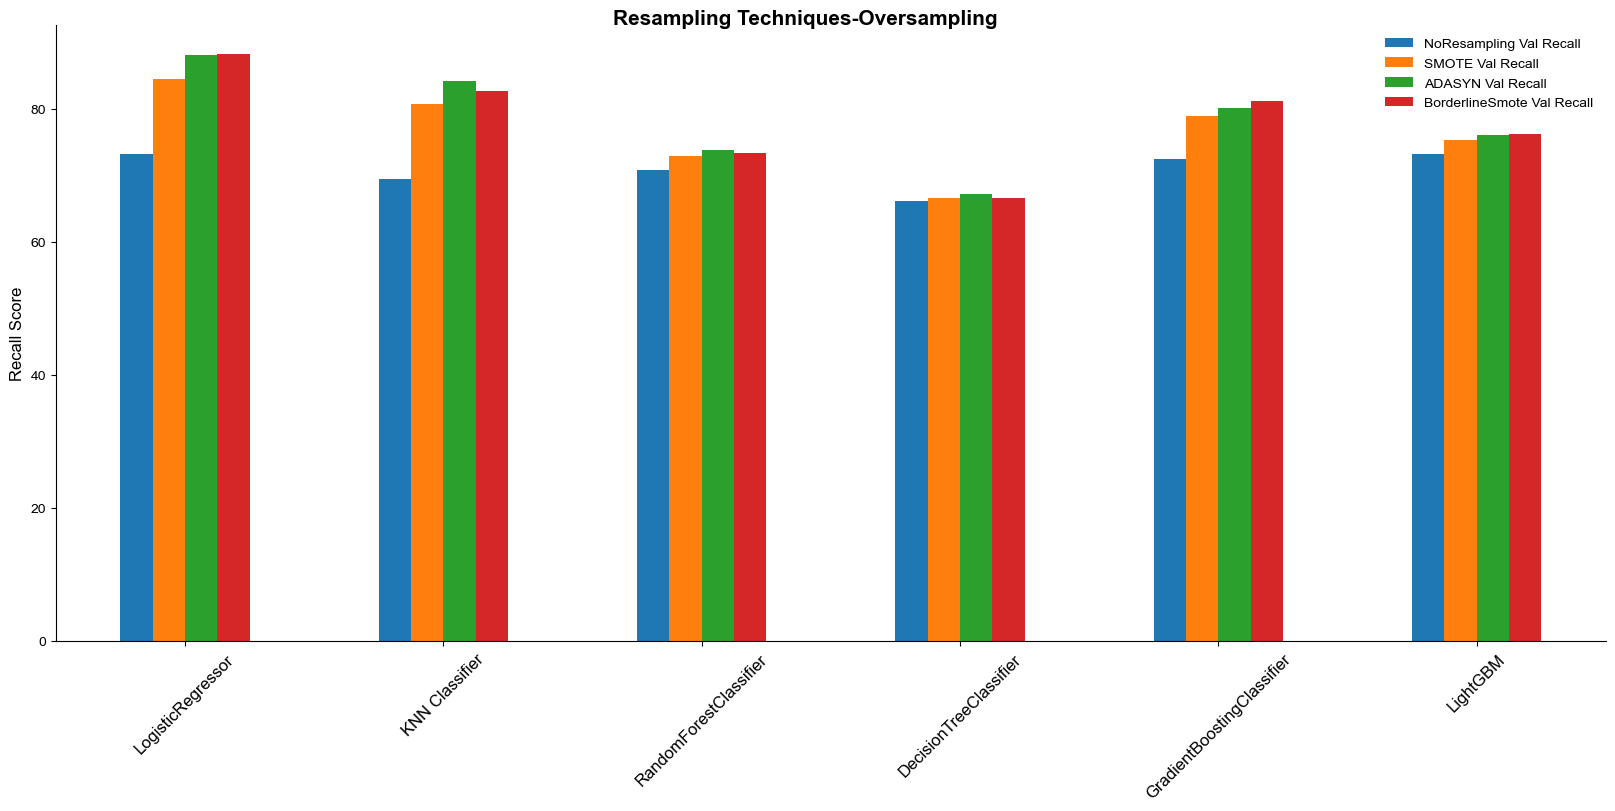

In [166]:
fig, ax = plt.subplots(figsize=(20, 8))
ps_over.plot.bar(ax=ax)
ax.set_ylabel('Recall Score', fontsize=12)
for spine in ['right', 'top']:
        ax.spines[spine].set_visible(False)
ax.legend(edgecolor='white')
fig.suptitle("Resampling Techniques-Oversampling", size=15, y=0.9, weight='bold')
plt.xticks(rotation=45, fontsize=12)
plt.show()

##### ii) Undersampling techniques

In [167]:
res_list = [('TomekLinks', TomekLinks()),
            ('NearMiss', NearMiss())]

outputs_u = []
for title, res in res_list:
    print(colored(title, 'red', attrs=['bold']).center(120, "-"))
    var = auto_ml(X_trainval, y_trainval, models_dict, scaler=RobustScaler(),
                  cv=StratifiedKFold(n_splits=5), res_t=res)
    outputs_u.append(var[0])
    display(var[1])

------------------------------------------------TomekLinks-------------------------------------------------


  0%|          | 0/6 [00:00<?, ?it/s]

0it [00:00, ?it/s]

Resampling done in 0.132673978805542
Resampling done in 0.2157588005065918
Resampling done in 0.19506192207336426
Resampling done in 0.2069540023803711
Resampling done in 0.2655141353607178


0it [00:00, ?it/s]

...

0it [00:00, ?it/s]

Resampling done in 0.0832211971282959
Resampling done in 0.05459189414978027
Resampling done in 0.05463910102844238
Resampling done in 0.055335283279418945
Resampling done in 0.05354595184326172


0it [00:00, ?it/s]

Resampling done in 0.05416607856750488
Resampling done in 0.05484318733215332
Resampling done in 0.05504012107849121
Resampling done in 0.055451154708862305
Resampling done in 0.05553102493286133


,Train Accuracy,Val Accuracy,Train Recall,Val Recall,Train AUC,Val AUC,Run Time
LogisticRegressor,77.19%,85.71%,77.28%,77.12%,84.76%,92.00%,0.055787
KNN Classifier,79.27%,81.28%,77.98%,72.33%,87.27%,85.00%,0.361086
RandomForestClassifier,99.41%,83.30%,99.29%,73.90%,99.99%,88.34%,0.543048
DecisionTreeClassifier,99.43%,72.19%,98.85%,67.16%,99.99%,70.83%,0.016805
GradientBoostingClassifier,78.31%,85.13%,77.17%,75.54%,86.40%,91.00%,0.315187
LightGBM,83.05%,84.41%,81.12%,74.80%,91.16%,89.91%,0.40739


In [168]:
ps_under = pd.DataFrame(index=models_dict.keys())
ps_under['NoResampling Val Recall'] = auto_run[0]['Val Recall']
ps_under['TomekLinks Val Recall'] = outputs_u[0]['Val Recall']
ps_under['NearMiss Val Recall'] = outputs_u[1]['Val Recall']
ps_under

,NoResampling Val Recall,TomekLinks Val Recall,NearMiss Val Recall
LogisticRegressor,73.17,77.28,77.12
KNN Classifier,69.48,73.24,72.33
RandomForestClassifier,70.82,74.22,73.90
DecisionTreeClassifier,66.10,69.38,67.16
GradientBoostingClassifier,72.46,76.60,75.54
LightGBM,73.24,76.49,74.80


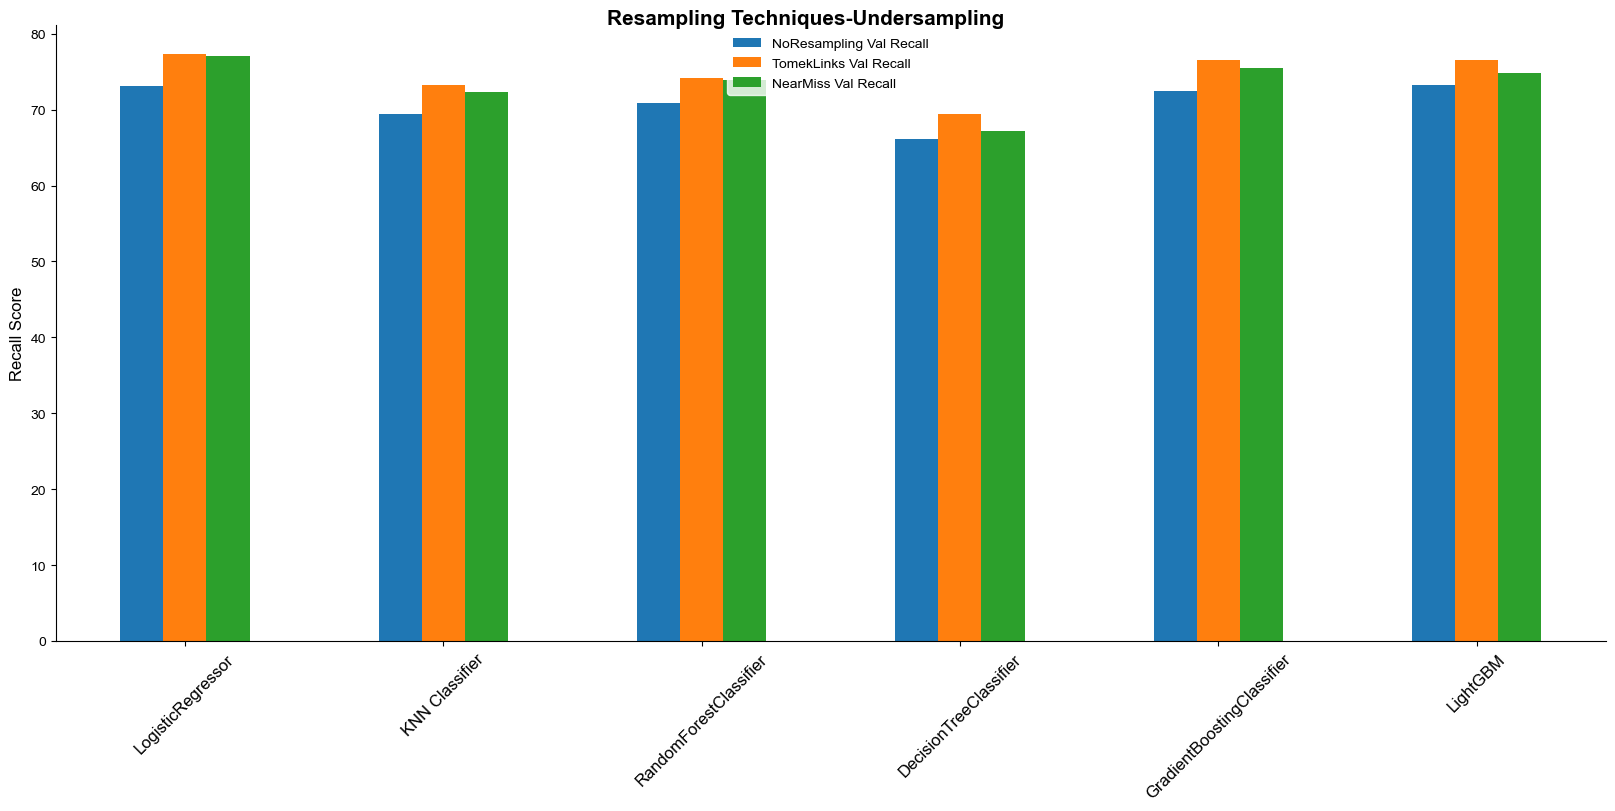

In [169]:
fig, ax = plt.subplots(figsize=(20, 8))
ps_under.plot.bar(ax=ax)
ax.set_ylabel('Recall Score', fontsize=12)
for spine in ['right', 'top']:
        ax.spines[spine].set_visible(False)
ax.legend(edgecolor='white')
fig.suptitle("Resampling Techniques-Undersampling", size=15, y=0.9, weight='bold')
plt.xticks(rotation=45, fontsize=12)
plt.show()

#### c. Hyperparameter tuning

##### i) Logistic Regression with BorderlineSMOTE

In [170]:
def train_lr(X, y, metric, res_t=None, hypertune=False, resample=False):
    params = {
        "logisticregression__C": [0.01, 0.1, 1, 10, 100],
        "logisticregression__penalty": ["l1", "l2", "elasticnet"],
        "logisticregression__solver": ["saga"],
        "logisticregression__max_iter": [100, 200, 500],
        "logisticregression__l1_ratio": [0.1, 0.5, 0.9]  # only used when penalty='elasticnet'
    }

    skf = StratifiedKFold(n_splits=3)

    # Use ColumnTransformer to scale only num_col
    preprocessor = ColumnTransformer(transformers=[
        ('scaler', RobustScaler(), num_col)
    ], remainder='passthrough')

    if resample is True:
        imba_pipeline = make_pipeline(preprocessor, res_t, LogisticRegression(random_state=42))
    else:
        imba_pipeline = make_pipeline(preprocessor, LogisticRegression(random_state=42))

    if hypertune is True:
        clf = RandomizedSearchCV(imba_pipeline, param_distributions=params,
                                 n_iter=100,
                                 cv=skf, scoring=metric,
                                 return_train_score=True,
                                 random_state=42,
                                 verbose=10,
                                 n_jobs=-1)
        start_time = time.time()
        clf.fit(X, y)
        run_time = time.time() - start_time
        model = clf.best_estimator_.fit(X, y)
        return ['Logistic Regression',
                np.mean(clf.cv_results_['mean_train_score']),
                clf.best_score_,
                'Best parameters = {0}'.format(clf.best_params_),
                run_time,
                model]
    else:
        clf = imba_pipeline
        start_time = time.time()
        clf.fit(X, y)
        run_time = time.time() - start_time
        cv_scores = cross_validate(estimator=clf, X=X, y=y,
                                   scoring=metric, cv=skf, n_jobs=-1,
                                   return_train_score=True)
        return ['Logistic Regression',
                np.mean(cv_scores['train_score']),
                np.mean(cv_scores['test_score']),
                run_time,
                clf]

In [171]:
start_time = time.time()
lr_bs_rec = train_lr(X_trainval, y_trainval, 'recall', BorderlineSMOTE(random_state=42),
                     hypertune=True, resample=True)

# hypertuned with accuracy
start_time = time.time()
lr_bs_acc = train_lr(X_trainval, y_trainval, 'accuracy', BorderlineSMOTE(random_state=42),
                     hypertune=True, resample=True)

Fitting 3 folds for each of 100 candidates, totalling 300 fits
[CV 3/3; 2/100] START logisticregression__C=1, logisticregression__l1_ratio=0.5, logisticregression__max_iter=200, logisticregression__penalty=l2, logisticregression__solver=saga
[CV 1/3; 1/100] START logisticregression__C=10, logisticregression__l1_ratio=0.5, logisticregression__max_iter=500, logisticregression__penalty=elasticnet, logisticregression__solver=saga
[CV 2/3; 1/100] START logisticregression__C=10, logisticregression__l1_ratio=0.5, logisticregression__max_iter=500, logisticregression__penalty=elasticnet, logisticregression__solver=saga
[CV 1/3; 2/100] START logisticregression__C=1, logisticregression__l1_ratio=0.5, logisticregression__max_iter=200, logisticregression__penalty=l2, logisticregression__solver=saga
[CV 2/3; 2/100] START logisticregression__C=1, logisticregression__l1_ratio=0.5, logisticregression__max_iter=200, logisticregression__penalty=l2, logisticregression__solver=saga
[CV 1/3; 3/100] START lo

In [172]:
lr_bs_rec

['Logistic Regression',
 np.float64(0.8849371564274388),
 np.float64(0.8875141580038961),
 "Best parameters = {'logisticregression__solver': 'saga', 'logisticregression__penalty': 'l2', 'logisticregression__max_iter': 100, 'logisticregression__l1_ratio': 0.9, 'logisticregression__C': 0.01}",
 10.960200071334839,
 Pipeline(steps=[('columntransformer',
                  ColumnTransformer(remainder='passthrough',
                                    transformers=[('scaler', RobustScaler(),
                                                   ['work_study_hours'])])),
                 ('borderlinesmote', BorderlineSMOTE(random_state=42)),
                 ('logisticregression',
                  LogisticRegression(C=0.01, l1_ratio=0.9, random_state=42,
                                     solver='saga'))])]

In [173]:
lr_bs_acc

['Logistic Regression',
 np.float64(0.8218360719087038),
 np.float64(0.8212015088288954),
 "Best parameters = {'logisticregression__solver': 'saga', 'logisticregression__penalty': 'elasticnet', 'logisticregression__max_iter': 500, 'logisticregression__l1_ratio': 0.5, 'logisticregression__C': 0.1}",
 6.863659143447876,
 Pipeline(steps=[('columntransformer',
                  ColumnTransformer(remainder='passthrough',
                                    transformers=[('scaler', RobustScaler(),
                                                   ['work_study_hours'])])),
                 ('borderlinesmote', BorderlineSMOTE(random_state=42)),
                 ('logisticregression',
                  LogisticRegression(C=0.1, l1_ratio=0.5, max_iter=500,
                                     penalty='elasticnet', random_state=42,
                                     solver='saga'))])]

In [174]:
# results table
cols = ['', 'Train Accuracy', 'Val Accuracy', 'Train Recall', 'Val Recall']
hyper = pd.DataFrame(columns=cols)
hyper.loc[0] = [lr_bs_rec[0],
                np.round(lr_bs_acc[1] * 100, 6),
                np.round(lr_bs_acc[2] * 100, 6),
                np.round(lr_bs_rec[1] * 100, 6),
                np.round(lr_bs_rec[2] * 100, 6)]

hyper2 = pd.DataFrame(columns=cols)
hyper2.loc[0] = [lr_bs_rec[0],
                 '{:.2f}%'.format(np.round(lr_bs_acc[1] * 100, 2)),
                 '{:.2f}%'.format(np.round(lr_bs_acc[2] * 100, 2)),
                 '{:.2f}%'.format(np.round(lr_bs_rec[1] * 100, 2)),
                 '{:.2f}%'.format(np.round(lr_bs_rec[2] * 100, 2))]
hyper2

,,Train Accuracy,Val Accuracy,Train Recall,Val Recall
0,Logistic Regression,82.18%,82.12%,88.49%,88.75%


<h5> Baseline-Hypertuned comparison

In [194]:
# re-fitting best model on full trainval for holdout evaluation
rh = lr_bs_rec[-1]
rh.fit(X_trainval, y_trainval)
y_preds = rh.predict(X_holdout)
rh_holdout_score = recall_score(y_holdout, y_preds)
print(f'Hypertuned Holdout Recall: {rh_holdout_score:.4f}')

Hypertuned Holdout Recall: 0.8890


In [176]:
# baseline (no resampling, no hypertuning)
base_var = train_lr(X_trainval, y_trainval, 'recall', hypertune=False, resample=False)
base_model = base_var[-1]
base_model.fit(X_trainval, y_trainval)
y_preds = base_model.predict(X_holdout)
holdout_score = recall_score(y_holdout, y_preds)
print(f'Baseline Holdout Recall: {holdout_score:.4f}')

Baseline Holdout Recall: 0.7397


In [177]:
cols = ['Method', 'Train Recall', 'Val Recall', 'Holdout Recall']
summary = pd.DataFrame(columns=cols)
summary.loc[0] = ['No Resampling',
                 '{:.2f}%'.format(np.round(base_var[1]*100, 2)),
                 '{:.2f}%'.format(np.round(base_var[2]*100, 2)),
                 '{:.2f}%'.format(np.round(holdout_score*100, 2))]
summary.loc[3] = ['Resampling x Hypertune',
                 '{:.2f}%'.format(np.round(lr_bs_rec[1]*100, 2)),
                 '{:.2f}%'.format(np.round(lr_bs_rec[2]*100, 2)),
                 '{:.2f}%'.format(np.round(rh_holdout_score*100, 2))]
summary

,Method,Train Recall,Val Recall,Holdout Recall
0,No Resampling,73.43%,73.32%,73.97%
3,Resampling x Hypertune,88.49%,88.75%,88.90%


##### ii) LightGBM with BordelineSMOTE

In [178]:
def train_lgbm(X, y, metric, res_t=None, hypertune=False, resample=False):
    params = {
        "lgbmclassifier__n_estimators": [50, 100, 200],
        "lgbmclassifier__learning_rate": [0.01, 0.05, 0.1],
        "lgbmclassifier__max_depth": [3, 5, 7],
        "lgbmclassifier__num_leaves": [20, 31, 50],
        "lgbmclassifier__min_child_samples": [10, 20, 30],
        "lgbmclassifier__subsample": [0.6, 0.8, 1.0],
        "lgbmclassifier__colsample_bytree": [0.6, 0.8, 1.0],
        "lgbmclassifier__reg_alpha": [0, 0.1, 0.5],
        "lgbmclassifier__reg_lambda": [0, 0.1, 0.5]
    }

    skf = StratifiedKFold(n_splits=3)

    # Use ColumnTransformer to scale only num_col
    preprocessor = ColumnTransformer(transformers=[
        ('scaler', RobustScaler(), num_col)
    ], remainder='passthrough')

    if resample is True:
        imba_pipeline = make_pipeline(preprocessor, res_t, LGBMClassifier(random_state=42, verbose=-1))
    else:
        imba_pipeline = make_pipeline(preprocessor, LGBMClassifier(random_state=42, verbose=-1))

    if hypertune is True:
        clf = RandomizedSearchCV(imba_pipeline, param_distributions=params,
                                 n_iter=100,
                                 cv=skf, scoring=metric,
                                 return_train_score=True,
                                 random_state=42,
                                 verbose=10,
                                 n_jobs=-1)
        start_time = time.time()
        clf.fit(X, y)
        run_time = time.time() - start_time
        model = clf.best_estimator_.fit(X, y)
        return ['LightGBM',
                np.mean(clf.cv_results_['mean_train_score']),
                clf.best_score_,
                'Best parameters = {0}'.format(clf.best_params_),
                run_time,
                model]
    else:
        clf = imba_pipeline
        start_time = time.time()
        clf.fit(X, y)
        run_time = time.time() - start_time
        cv_scores = cross_validate(estimator=clf, X=X, y=y,
                                   scoring=metric, cv=skf, n_jobs=-1,
                                   return_train_score=True)
        return ['LightGBM',
                np.mean(cv_scores['train_score']),
                np.mean(cv_scores['test_score']),
                run_time,
                clf]

In [179]:
start_time = time.time()
lgbm_bs_rec = train_lgbm(X_trainval, y_trainval, 'recall', BorderlineSMOTE(random_state=42),
                          hypertune=True, resample=True)

# hypertuned with accuracy
start_time = time.time()
lgbm_bs_acc = train_lgbm(X_trainval, y_trainval, 'accuracy', BorderlineSMOTE(random_state=42),
                          hypertune=True, resample=True)

Fitting 3 folds for each of 100 candidates, totalling 300 fits
[CV 1/3; 1/100] START lgbmclassifier__colsample_bytree=1.0, lgbmclassifier__learning_rate=0.05, lgbmclassifier__max_depth=3, lgbmclassifier__min_child_samples=30, lgbmclassifier__n_estimators=50, lgbmclassifier__num_leaves=20, lgbmclassifier__reg_alpha=0, lgbmclassifier__reg_lambda=0, lgbmclassifier__subsample=0.6
[CV 1/3; 2/100] START lgbmclassifier__colsample_bytree=0.6, lgbmclassifier__learning_rate=0.01, lgbmclassifier__max_depth=5, lgbmclassifier__min_child_samples=10, lgbmclassifier__n_estimators=100, lgbmclassifier__num_leaves=31, lgbmclassifier__reg_alpha=0.5, lgbmclassifier__reg_lambda=0.1, lgbmclassifier__subsample=1.0
[CV 3/3; 1/100] START lgbmclassifier__colsample_bytree=1.0, lgbmclassifier__learning_rate=0.05, lgbmclassifier__max_depth=3, lgbmclassifier__min_child_samples=30, lgbmclassifier__n_estimators=50, lgbmclassifier__num_leaves=20, lgbmclassifier__reg_alpha=0, lgbmclassifier__reg_lambda=0, lgbmclassifier

In [180]:
lgbm_bs_rec

['LightGBM',
 np.float64(0.8363216072904209),
 np.float64(0.8630507306045367),
 "Best parameters = {'lgbmclassifier__subsample': 0.8, 'lgbmclassifier__reg_lambda': 0.5, 'lgbmclassifier__reg_alpha': 0.5, 'lgbmclassifier__num_leaves': 31, 'lgbmclassifier__n_estimators': 50, 'lgbmclassifier__min_child_samples': 20, 'lgbmclassifier__max_depth': 3, 'lgbmclassifier__learning_rate': 0.01, 'lgbmclassifier__colsample_bytree': 1.0}",
 91.46909213066101,
 Pipeline(steps=[('columntransformer',
                  ColumnTransformer(remainder='passthrough',
                                    transformers=[('scaler', RobustScaler(),
                                                   ['work_study_hours'])])),
                 ('borderlinesmote', BorderlineSMOTE(random_state=42)),
                 ('lgbmclassifier',
                  LGBMClassifier(learning_rate=0.01, max_depth=3,
                                 n_estimators=50, random_state=42, reg_alpha=0.5,
                                 reg_lambd

In [181]:
lgbm_bs_acc

['LightGBM',
 np.float64(0.8500643193875093),
 np.float64(0.8551756290093188),
 "Best parameters = {'lgbmclassifier__subsample': 1.0, 'lgbmclassifier__reg_lambda': 0, 'lgbmclassifier__reg_alpha': 0, 'lgbmclassifier__num_leaves': 31, 'lgbmclassifier__n_estimators': 200, 'lgbmclassifier__min_child_samples': 30, 'lgbmclassifier__max_depth': 3, 'lgbmclassifier__learning_rate': 0.1, 'lgbmclassifier__colsample_bytree': 0.6}",
 149.82466101646423,
 Pipeline(steps=[('columntransformer',
                  ColumnTransformer(remainder='passthrough',
                                    transformers=[('scaler', RobustScaler(),
                                                   ['work_study_hours'])])),
                 ('borderlinesmote', BorderlineSMOTE(random_state=42)),
                 ('lgbmclassifier',
                  LGBMClassifier(colsample_bytree=0.6, max_depth=3,
                                 min_child_samples=30, n_estimators=200,
                                 random_state=42, re

In [182]:
# results table
cols = ['', 'Train Accuracy', 'Val Accuracy', 'Train Recall', 'Val Recall']
hyper = pd.DataFrame(columns=cols)
hyper.loc[0] = [lgbm_bs_rec[0],
                np.round(lgbm_bs_acc[1] * 100, 6),
                np.round(lgbm_bs_acc[2] * 100, 6),
                np.round(lgbm_bs_rec[1] * 100, 6),
                np.round(lgbm_bs_rec[2] * 100, 6)]

hyper2 = pd.DataFrame(columns=cols)
hyper2.loc[0] = [lgbm_bs_rec[0],
                 '{:.2f}%'.format(np.round(lgbm_bs_acc[1] * 100, 2)),
                 '{:.2f}%'.format(np.round(lgbm_bs_acc[2] * 100, 2)),
                 '{:.2f}%'.format(np.round(lgbm_bs_rec[1] * 100, 2)),
                 '{:.2f}%'.format(np.round(lgbm_bs_rec[2] * 100, 2))]
hyper2

,,Train Accuracy,Val Accuracy,Train Recall,Val Recall
0,LightGBM,85.01%,85.52%,83.63%,86.31%


## 8. Model Performance Evaluation

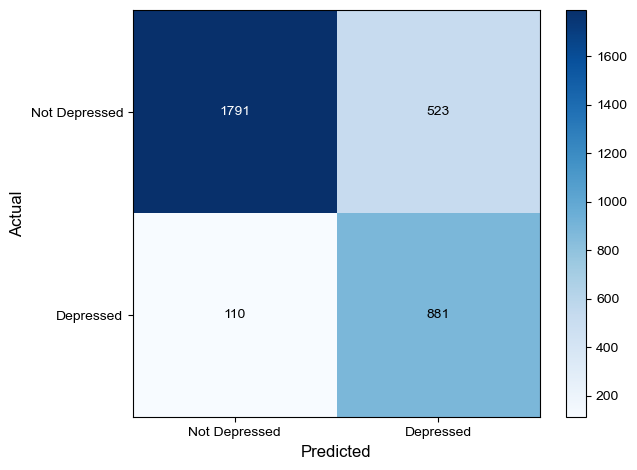

In [195]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_holdout, 
    y_preds,
    colorbar=True,
    display_labels=['Not Depressed', 'Depressed']  # replace 0/1 with readable labels
)
disp.im_.set_cmap('Blues')

# Set text color based on background brightness
thresh = disp.im_.norm(disp.confusion_matrix.max()) / 2
for text in disp.text_.ravel():
    val = disp.im_.norm(float(text.get_text()))
    text.set_color('white' if val > thresh else 'black')

# improve axis labels
disp.ax_.set_xlabel('Predicted', fontsize=12)
disp.ax_.set_ylabel('Actual', fontsize=12)

# rotate tick labels for readability
disp.ax_.set_xticklabels(['Not Depressed', 'Depressed'], rotation=0, fontsize=10)
disp.ax_.set_yticklabels(['Not Depressed', 'Depressed'], rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

In [196]:
from sklearn.metrics import classification_report
print(classification_report(y_holdout, y_preds))

              precision    recall  f1-score   support

           0       0.94      0.77      0.85      2314
           1       0.63      0.89      0.74       991

    accuracy                           0.81      3305
   macro avg       0.78      0.83      0.79      3305
weighted avg       0.85      0.81      0.82      3305



In [197]:
accuracy = accuracy_score(y_holdout, y_preds)
recall = recall_score(y_holdout, y_preds)
auc = roc_auc_score(y_holdout, rh.predict_proba(X_holdout)[:, 1])

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Recall', 'AUC'],
    'Score': [
        '{:.2f}%'.format(accuracy * 100),
        '{:.2f}%'.format(recall * 100),
        '{:.2f}%'.format(auc * 100)
    ]
}).set_index('Metric')

metrics_df

,Score
Metric,
Accuracy,80.85%
Recall,88.90%
AUC,91.77%


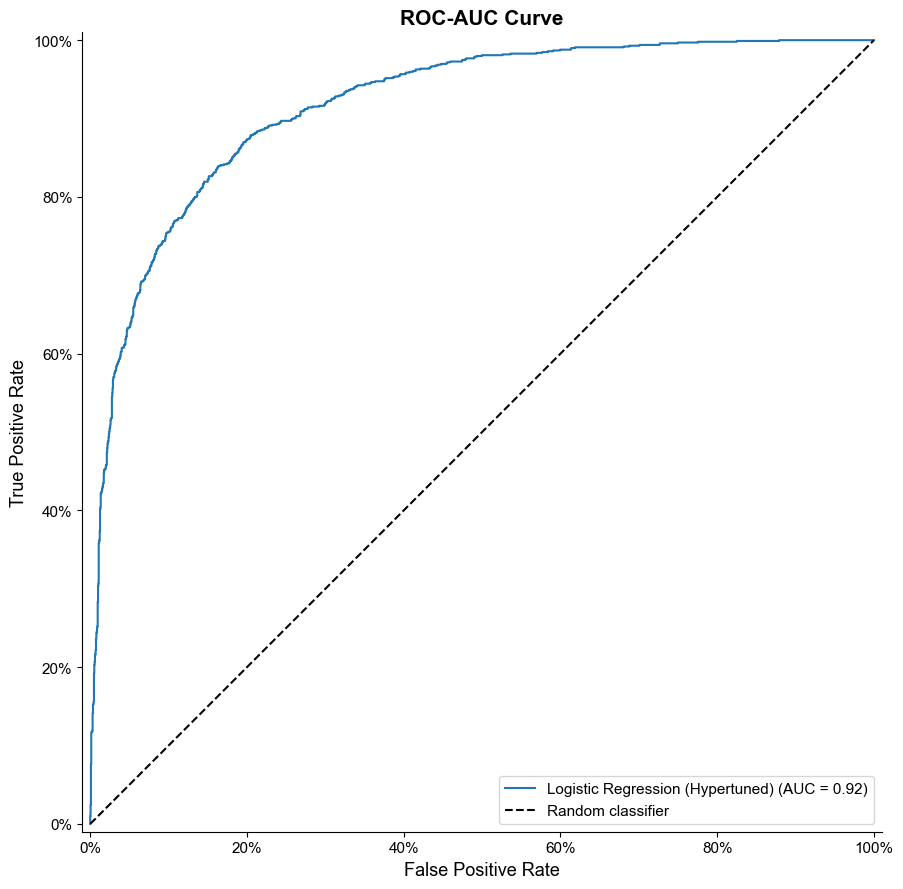

In [198]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 9))

RocCurveDisplay.from_predictions(
    y_holdout,
    rh.predict_proba(X_holdout)[:, 1],
    name='Logistic Regression (Hypertuned)',
    ax=ax
)

ax.plot([0, 1], [0, 1], 'k--', label='Random classifier')

# Axis labels
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC-AUC Curve', fontsize=15, fontweight='bold')

# Tick labels
ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_xticklabels(['0%', '20%', '40%', '60%', '80%', '100%'], fontsize=11)
ax.set_yticklabels(['0%', '20%', '40%', '60%', '80%', '100%'], fontsize=11)

# Clean up spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(fontsize=11, loc='lower right')
plt.tight_layout()
plt.show()

## 9. Model Interpretability

In [199]:
# save model
pickle.dump(rh, open('lr_bs.pkl', 'wb'))

# load pipeline
model = pickle.load(open('lr_bs.pkl', 'rb'))

# Extract components
preprocessor_step = model.named_steps['columntransformer']
estimator = model.named_steps['logisticregression']

# Apply preprocessor to holdout
X_holdout_transformed = preprocessor_step.transform(X_holdout)

# Clean feature names
feature_names = [
    col.split("__", 1)[-1] for col in preprocessor_step.get_feature_names_out()
]

# Convert to DataFrame
X_holdout_df = pd.DataFrame(
    X_holdout_transformed,
    columns=feature_names,
    index=X_holdout.index
)

In [200]:
# SHAP
explainer = shap.LinearExplainer(estimator, X_holdout_df)
shap_values = explainer.shap_values(X_holdout_df)

In [201]:
# SHAP summary dataframe
shap_df = pd.DataFrame(shap_values, columns=feature_names, index=X_holdout.index)
shap_summary = pd.DataFrame({
    'mean_shap': shap_df.mean(),
    'mean_abs_shap': shap_df.abs().mean()
}).sort_values('mean_abs_shap', ascending=False)

shap_summary

,mean_shap,mean_abs_shap
suicidal_thoughts,0.014616,1.116991
academic_pressure,-0.120695,0.807275
financial_stress,0.065234,0.563578
age_group,0.041622,0.343789
work_study_hours,0.053929,0.321475
dietary_habits,-0.012673,0.303456
study_satisfaction,0.021178,0.243016
sleep_duration,0.020076,0.168481
family_history_mental_illness,-0.011545,0.077698
degree_level,0.000245,0.002713


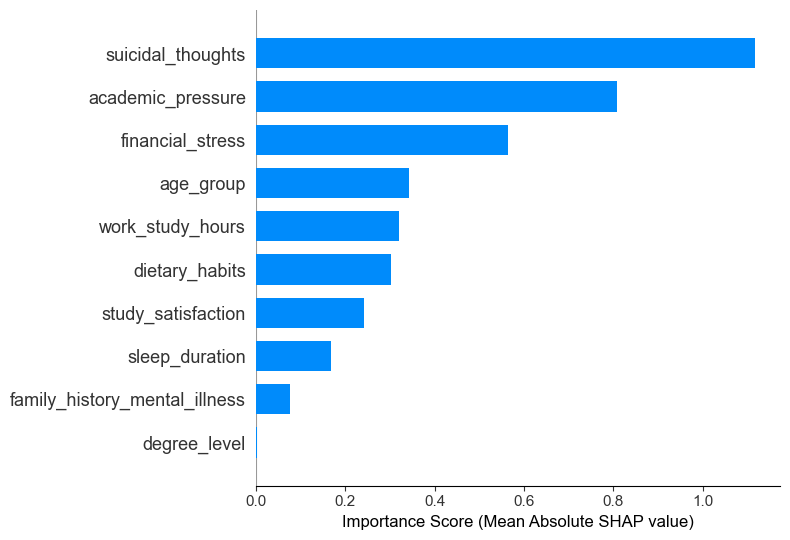

In [202]:
# Close any existing figures first
plt.close('all')

# Generate SHAP plot
shap.summary_plot(shap_values, X_holdout_df, feature_names=feature_names, plot_type='bar', show=False)

# Override the x-axis label on the current active figure
plt.xlabel("Importance Score (Mean Absolute SHAP value)", fontsize=12)
plt.tight_layout()
plt.show()

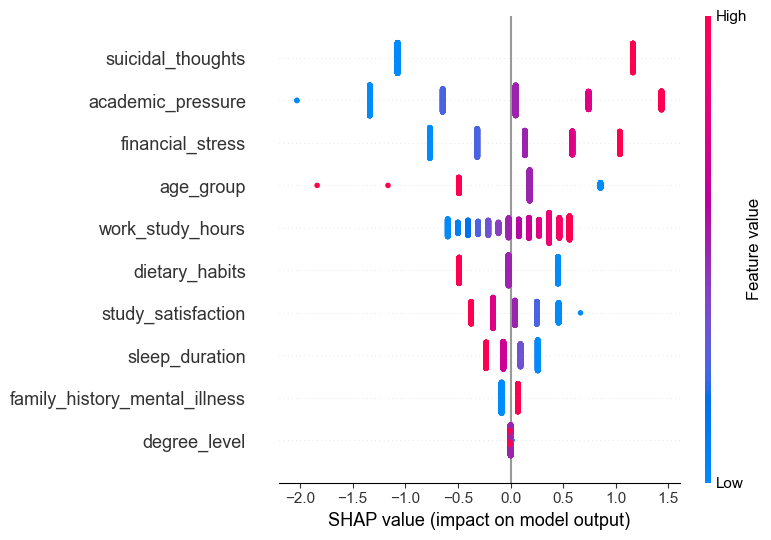

In [203]:
shap.summary_plot(shap_values, X_holdout_df, feature_names=feature_names)

## 10. Conclusion

Strongest relators to depression with highest positive correlations were found to be: suicidal thoughts, academic pressure, financial stress, work/study hours. This suggests that a student’s **Lifestyle & Wellbeing** may play a more significant role in depression. 

In terms of predicting depression, academic pressure, financial stress, and age group are the strongest indicators of depression risk in our model. Our best model was selected to be Logistic Regression with BorderlineSMOTE (hypertuned) with an ROC-AUC value of 91.77%.

As a call to action, we are recommending for students to promote lifestyle & well-being through structured routines, implement campus wellness programs, improve access to counseling services and peer support groups, and to encourage healthy coping mechanisms.